# Librairies and data

In [1]:
from torch.utils.data import DataLoader

import os, time, datetime

import sys
sys.path.append('../../py_scripts')

from SPAC_Dataset import dataset
from models import *

## T2T

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches
import matplotlib.colors as plc
import cooler
import string
from numpy.lib.stride_tricks import as_strided


good_gid = "HG002.H1"

good_cool = cooler.Cooler(f"/home/amergez/SPA-C/datasets_v2/{good_gid}/aligned/{good_gid}.JHE.mcool::/resolutions/5000")
good_mat = good_cool.matrix(balance=False)

def parse_matrices(ctg1, s1, e1, ctg2, s2, e2, o1, o2, cool):
    mat = cool.matrix(balance=False)
    chromsizes = cool.chromsizes.to_dict()

    T1 = (ctg1, int(s1//5000*5000), int(e1//5000*5000))


    if o1 == "F":
        c1 = np.array(mat.fetch(T1, T1))
    else:
        c1 = np.rot90(np.array(mat.fetch(T1, T1)), k=2)

    T2 = (ctg2, int(s2//5000*5000), int(e2//5000*5000))

    if o2 == "F":
        c2 = np.array(mat.fetch(T2, T2))
    else:
        c2 = np.rot90(np.array(mat.fetch(T2, T2)), k=2)

    if o1 == "F" and o2 == "F":
        c1x2 = np.array(mat.fetch(T1, T2))
        c2x1 = np.array(mat.fetch(T2, T1))
    elif o1 == "R" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0,1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0,1))
    elif o1 == "F" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0))
    elif o1 == "R" and o2 == "F":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (1))

    return c1, c2, c1x2, c2x1

import re

def reconstruct_mat(name, cool):
    if "|" in name:
        ctg1, s1, e1, ctg2, s2, e2 = re.split(r"\||:|-", name)
        s1, e1, s2, e2 = int(s1), int(e1), int(s2), int(e2)
        #print(ctg1, s1, e1, ctg2, s2, e2)
    else:
        ctg1, s1, e1 = re.split(r"\||:|-", name)
        s1, e1 = int(s1), int(e1)
        ctg2, s2, e2 = None, None, None
        #print(ctg1, s1, e1)

    # Orienting
    if s1 <= e1:
        o1, _s1, _e1 = "F", s1, e1
    else:
        o1, _s1, _e1 = "R", e1, s1
        
    if ctg2 is not None:
        # Orienting
        if s2 <= e2:
            o2, _s2, _e2 = "F", s2, e2
        else:
            o2, _s2, _e2 = "R", e2, s2
        
        c1, c2, c1x2, c2x1 = parse_matrices(ctg1, _s1, _e1, ctg2, _s2, _e2, o1, o2, cool)

        _shape = c1.shape[0]+c2.shape[0]
        _bp = c1.shape[0]
        FMAT = np.zeros((_shape, _shape))
        FMAT[:_bp, :_bp] = c1
        FMAT[_bp:, _bp:] = c2
        FMAT[_bp:, :_bp] = c2x1
        FMAT[:_bp, _bp:] = c1x2

    else:
        mat = cool.matrix(balance=False)
        T = (ctg1, int(_s1//5000*5000), int(_e1//5000*5000))
        FMAT = np.array(mat.fetch(T, T))

    return FMAT

# Figure

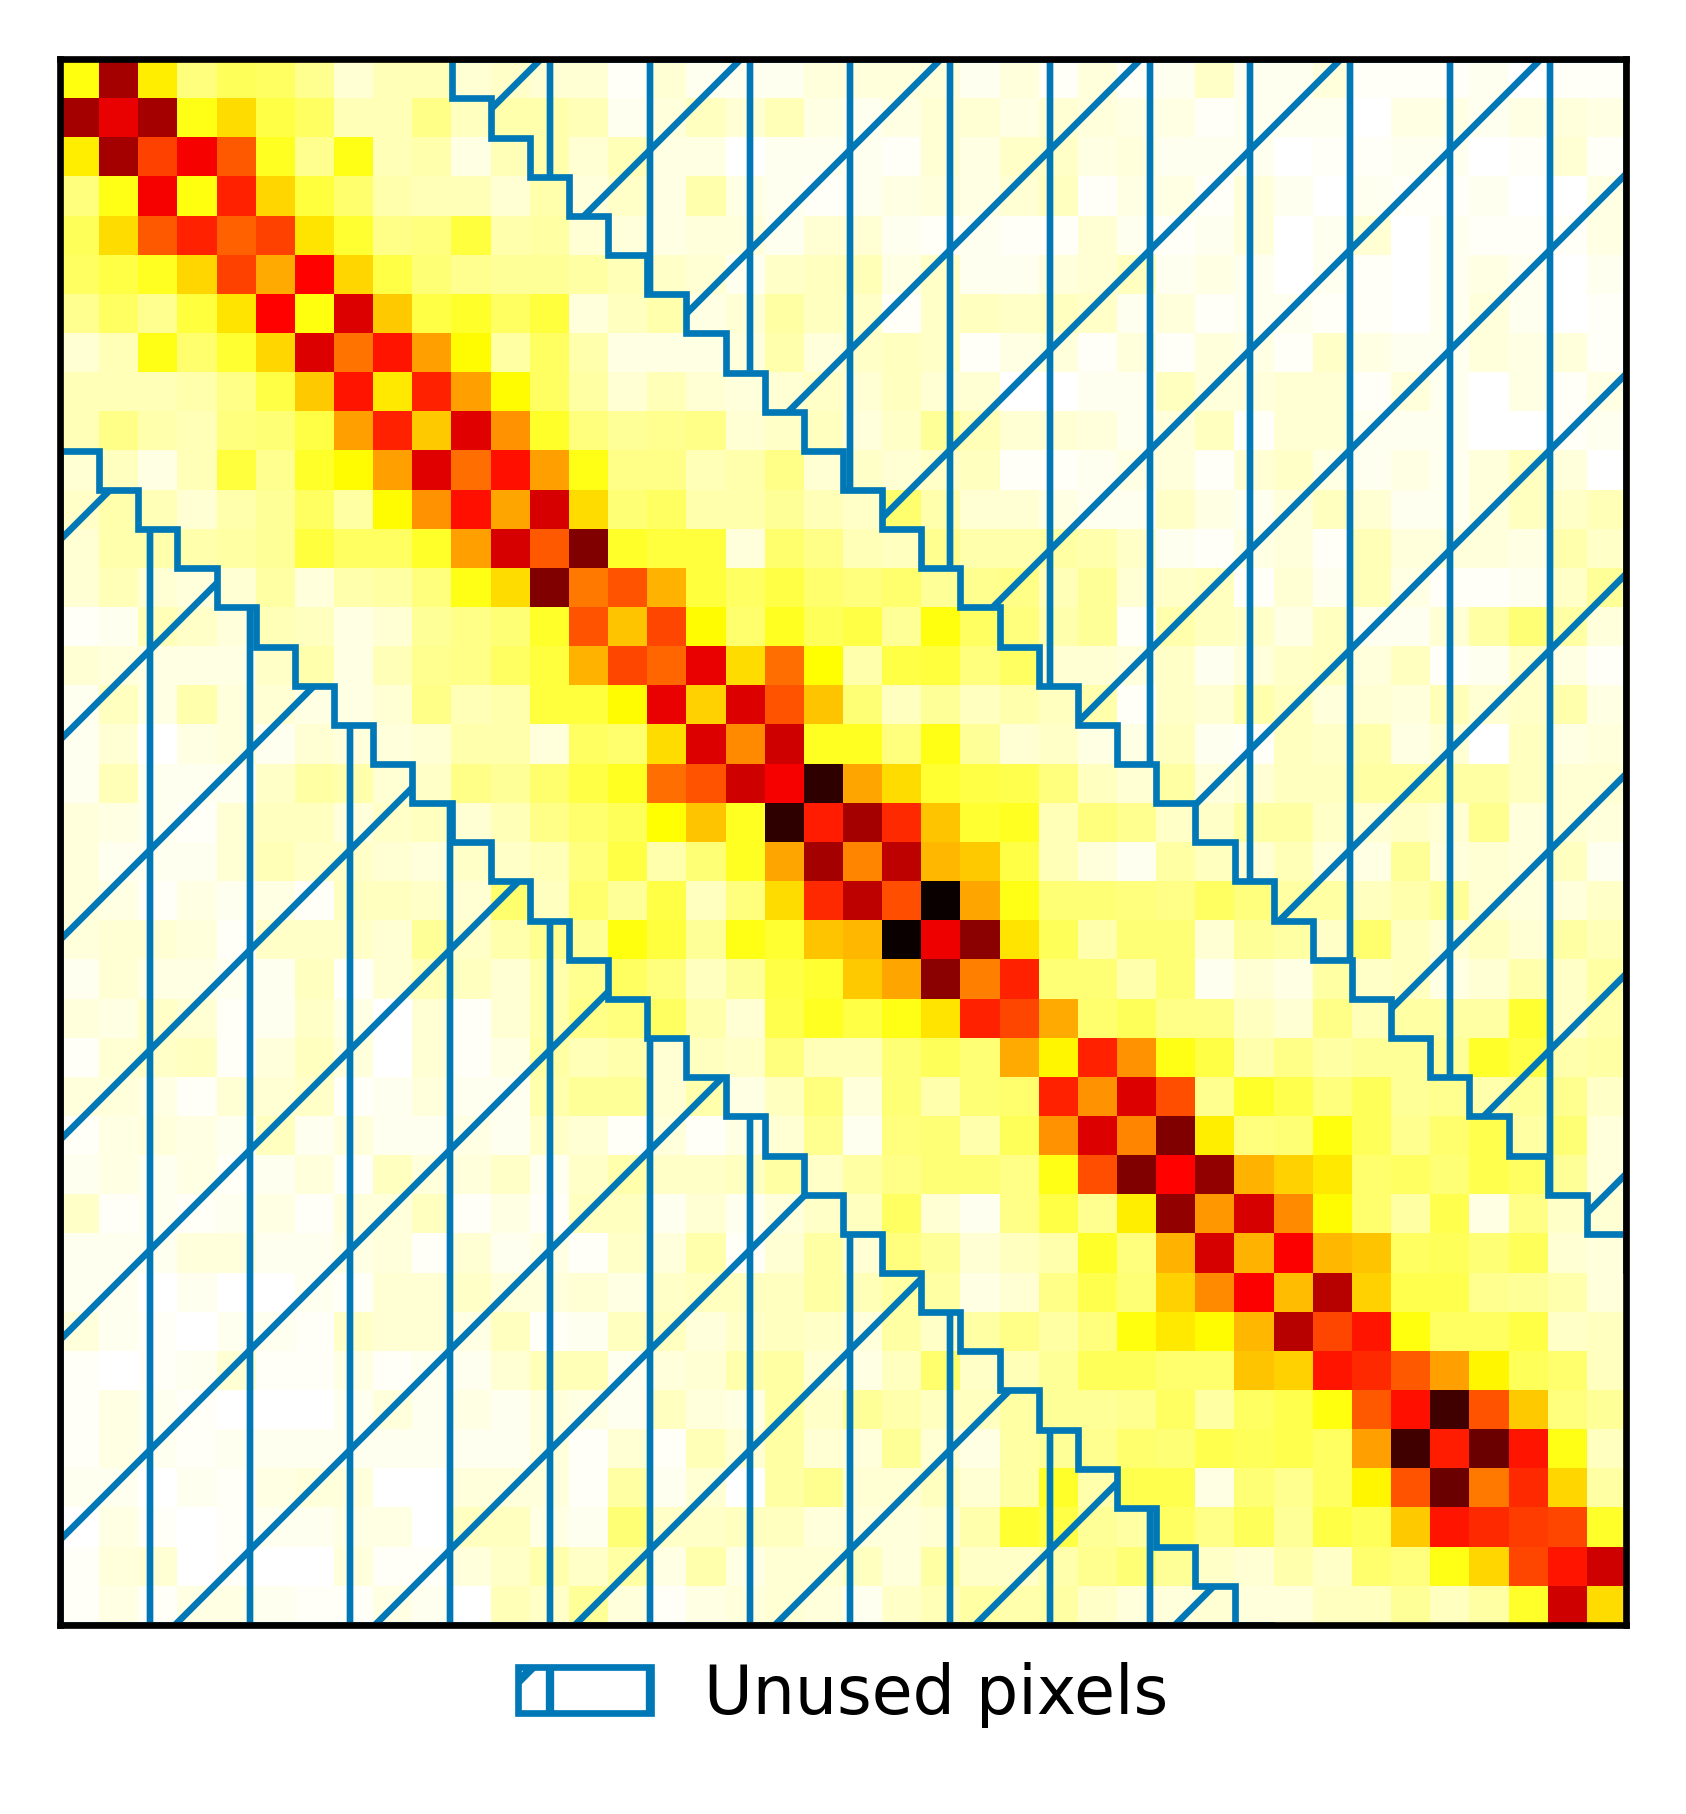

In [3]:

fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=600)

lw = 0.8
fs = 8

plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})

colors=["#03045e", "#0077b6", "#00b4d8", "#90e0ef"][::-1] # SOURCE : https://coolors.co/palette/03045e-0077b6-00b4d8-90e0ef-caf0f8 

mat = reconstruct_mat("chr1_MATERNAL:10000000-10200000", good_cool)
ax.matshow(mat, cmap="hot_r")
ax.tick_params(
        axis='both',          
        which='both',         
        bottom=False,         
        top=False,            
        left=False,           
        right=False,          
        labelbottom=False,    
        labeltop=False,       
        labelleft=False,      
        labelright=False      
    )

# Adding hatched patterns
## Top right
coords = [(0-.5, 40-.5)]

## Stair-like pattern
for i in range(len(np.diag(mat, k=10))+1):
    coords.append((i-.5, i+10-.5))
    coords.append((i+.5, i+10-.5))
    
pentagon = plt.Polygon(
    coords,
    closed=True,
    color="#0077b6",
    fill=False,
    linewidth=lw,
    hatch='/|',
    hatch_linewidth=lw
)
ax.add_patch(pentagon)

## Bottom left
coords = [(40-.5, 0-.5)]
## Stair-like pattern
for i in list(range(len(np.diag(mat, k=10))+1))[::-1]:
    coords.append((i+10-.5, i+.5))
    coords.append((i+10-.5, i-.5))

pentagon = plt.Polygon(
    coords,
    closed=True,
    color="#0077b6",
    fill=False,
    linewidth=lw,
    hatch='/|',
    hatch_linewidth=lw
)
ax.add_patch(pentagon)



hatch_proxy = mpatches.Patch(
    color="#0077b6",
    alpha=1,
    fill=False,
    label='',
    linewidth=lw,
    hatch='/|',
    hatch_linewidth=lw
)

fig.legend([hatch_proxy], ["Unused pixels"], loc='lower center', ncol=1, bbox_to_anchor=(0.5, 0), frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout(rect=(0, 0.05, 1, 1)) #(left, bottom, right, top)
plt.savefig(f"SUPP.PAPER.Normalisation.png")
plt.show()